In [ ]:
# This cell trains the model on the training dataset and evaluates it on the validation set per epoch.
# This cell performs specific operations related to model building, training, or evaluation.
## Cell 1: Unmount Google Drive if already mounted to avoid conflicts.
!fusermount -u /content/drive
!rm -rf /content/drive

fusermount: failed to unmount /content/drive: No such file or directory


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## Cell 2: Import Google Colab drive API to enable mounting of Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## Cell 3: Import Python's OS module for filesystem operations.
import os
print(os.listdir('/content/drive/MyDrive/AD-DATA'))

['CHANGES', 'dataset_description.json', 'README', 'participants.tsv', 'participants.json', 'sub-080', 'sub-088', 'sub-086', 'sub-087', 'sub-083', 'sub-084', 'sub-085', 'sub-079', 'sub-081', 'sub-082', 'sub-078', 'sub-076', 'sub-074', 'sub-075', 'sub-072', 'sub-070', 'sub-071', 'sub-069', 'sub-073', 'sub-068', 'sub-067', 'sub-065', 'sub-066', 'sub-064', 'sub-063', 'sub-062', 'sub-061', 'sub-060', 'sub-059', 'sub-058', 'sub-057', 'sub-056', 'sub-055', 'sub-053', 'sub-054', 'sub-052', 'sub-051', 'sub-050', 'sub-049', 'sub-048', 'sub-047', 'sub-045', 'sub-044', 'sub-046', 'sub-043', 'sub-042', 'sub-041', 'sub-040', 'sub-039', 'sub-038', 'sub-037', 'sub-036', 'sub-035', 'sub-034', 'sub-033', 'sub-032', 'sub-031', 'sub-030', 'sub-029', 'sub-028', 'sub-027', 'sub-026', 'sub-025', 'sub-024', 'sub-023', 'sub-022', 'sub-021', 'sub-020', 'sub-019', 'sub-018', 'sub-017', 'sub-016', 'sub-015', 'sub-014', 'sub-013', 'sub-012', 'sub-011', 'sub-010', 'sub-009', 'sub-008', 'sub-007', 'sub-006', 'sub-00

In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## Setup for Preprocessing — Install MNE & Basic Imports

# Install MNE (EEG/MEG processing library)
!pip install mne --quiet

# Imports
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 80.2 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## EEG Preprocessing ONLY — Saving Cleaned EEG Files

from glob import glob

# === Paths ===
base_derivatives_path = "/content/drive/MyDrive/AD-DATA/derivatives"
output_preproc_path = "/content/drive/MyDrive/preprocessed_data"
os.makedirs(output_preproc_path, exist_ok=True)

# === Loop Over Subjects ===
subject_folders = sorted(glob(os.path.join(base_derivatives_path, "sub-*")))
print(f"Found {len(subject_folders)} subjects.")

for subj_path in subject_folders:
    subj_id = os.path.basename(subj_path)
    eeg_file = os.path.join(subj_path, "eeg", f"{subj_id}_task-eyesclosed_eeg.set")

    if not os.path.exists(eeg_file):
        print(f"⚠️ Missing file for {subj_id}, skipping...")
        continue

    print(f"Preprocessing {subj_id}...")

    # Load EEG
    raw = mne.io.read_raw_eeglab(eeg_file, preload=True)

    # Set reference to Cz (fallback to average if Cz missing)
    if 'Cz' in raw.ch_names:
        raw.set_eeg_reference(ref_channels=['Cz'])
    else:
        print(f"⚠️ Cz not found for {subj_id}, using average reference.")
        raw.set_eeg_reference('average')

    # Apply basic bandpass filter (0.5–70 Hz)
    raw.filter(l_freq=0.5, h_freq=70)

    # Save preprocessed file
    save_path = os.path.join(output_preproc_path, f"{subj_id}_preprocessed_raw.fif")
    raw.save(save_path, overwrite=True)

print("✅ Preprocessing complete. Clean EEG files saved to:", output_preproc_path)

Found 88 subjects.
Preprocessing sub-001...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 3301 samples (6.602 s)

Writing /content/drive/MyDrive/preprocessed_data/sub-001_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-001_preprocessed_raw.fif
[done]
Preprocessing sub-002...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous seg

/tmp/ipython-input-3275018883.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


Writing /content/drive/MyDrive/preprocessed_data/sub-003_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-003_preprocessed_raw.fif
[done]
Preprocessing sub-004...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 3301 samples (6.602 s)



/tmp/ipython-input-3275018883.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


Writing /content/drive/MyDrive/preprocessed_data/sub-004_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-004_preprocessed_raw.fif
[done]
Preprocessing sub-005...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 3301 samples (6.602 s)

Writing /content/drive/MyDrive/preprocessed_data/sub-005_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-005_preprocessed_raw.fif
[done]
Pr

...

Writing /content/drive/MyDrive/preprocessed_data/sub-086_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-086_preprocessed_raw.fif
[done]
Preprocessing sub-087...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 3301 samples (6.602 s)



/tmp/ipython-input-3275018883.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


Writing /content/drive/MyDrive/preprocessed_data/sub-087_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-087_preprocessed_raw.fif
[done]
Preprocessing sub-088...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 3301 samples (6.602 s)



/tmp/ipython-input-3275018883.py:25: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


Writing /content/drive/MyDrive/preprocessed_data/sub-088_preprocessed_raw.fif
Closing /content/drive/MyDrive/preprocessed_data/sub-088_preprocessed_raw.fif
[done]
✅ Preprocessing complete. Clean EEG files saved to: /content/drive/MyDrive/preprocessed_data


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## Generate Topomap Images from Preprocessed EEG Data

# Install MNE if not already installed
!pip install mne --quiet

# Imports
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Paths
preproc_path = "/content/drive/MyDrive/AD-DATA/preprocessed_data"
output_topomap_path = "/content/drive/MyDrive/AD-DATA/topomaps_5bands_preprocessed"
os.makedirs(output_topomap_path, exist_ok=True)

# Frequency bands and colormaps
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45)
}
colormaps = {
    'delta': 'Blues',
    'theta': 'Greens',
    'alpha': 'Purples',
    'beta': 'Oranges',
    'gamma': 'Reds'
}

# Function to compute average band power
def compute_band_power(raw, fmin, fmax):
    psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)
    return psd.get_data().mean(axis=-1)

# Process all preprocessed EEG files
preproc_files = sorted(glob(os.path.join(preproc_path, "*_preprocessed_raw.fif")))
print(f"Found {len(preproc_files)} preprocessed EEG files.")

for file_path in preproc_files:
    subj_id = os.path.basename(file_path).split("_")[0]  # e.g., sub-001
    print(f"Generating topomaps for {subj_id}...")

    # Load preprocessed EEG
    raw = mne.io.read_raw_fif(file_path, preload=True)
    raw.set_montage('standard_1020', match_case=False)

    # Output directory for this subject
    subject_output_dir = os.path.join(output_topomap_path, subj_id)
    os.makedirs(subject_output_dir, exist_ok=True)

    # Generate and save topomaps
    for band, (fmin, fmax) in bands.items():
        power = compute_band_power(raw, fmin, fmax)
        fig, ax = plt.subplots()
        mne.viz.plot_topomap(power, raw.info, axes=ax, cmap=colormaps[band], show=False)
        fig.suptitle(f'{subj_id} - {band}', fontsize=12)
        fig.savefig(os.path.join(subject_output_dir, f'{subj_id}_{band}.png'))
        plt.close(fig)

print(f"✅ Topomap generation complete. Saved in: {output_topomap_path}")

Found 88 preprocessed EEG files.
Generating topomaps for sub-001...
Opening raw data file /content/drive/MyDrive/AD-DATA/preprocessed_data/sub-001_preprocessed_raw.fif...
    Range : 0 ... 299899 =      0.000 ...   599.798 secs
Ready.
Reading 0 ... 299899  =      0.000 ...   599.798 secs...
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)


/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)


Effective window size : 4.096 (s)


/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)
/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)


Effective window size : 4.096 (s)


...

/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)


Effective window size : 4.096 (s)


/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)


✅ Topomap generation complete. Saved in: /content/drive/MyDrive/AD-DATA/topomaps_5bands_preprocessed


/tmp/ipython-input-1963508894.py:36: UserWarning: Zero value in spectrum for channel Cz
  psd = raw.compute_psd(method='welch', fmin=fmin, fmax=fmax, n_fft=2048)


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
## Create CSVs for Binary Classification: (AD + FTD = 1, Control = 0) using participants.tsv
## Keeps participant_id and Group in output

import pandas as pd
import os
from glob import glob
from sklearn.model_selection import train_test_split

# Paths
topomap_base = "/content/drive/MyDrive/AD-DATA/topomaps_5bands_preprocessed"
participants_file = "/content/drive/MyDrive/AD-DATA/participants.tsv"
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# Load participant info
participants_df = pd.read_csv(participants_file, sep="\t")

# Map group labels: A/Alzheimer or F/FTD → 1, C/Control → 0
group_map = {'A': 1, 'F': 1, 'C': 0}
participants_df['label'] = participants_df['Group'].map(group_map)

# Create lookup dictionary: participant_id → (Group, label)
label_lookup = dict(zip(participants_df['participant_id'], zip(participants_df['Group'], participants_df['label'])))

# Collect image paths and labels
data_rows = []

subject_dirs = sorted(glob(os.path.join(topomap_base, "sub-*")))
for subj_dir in subject_dirs:
    subj_id = os.path.basename(subj_dir)  # e.g., sub-001

    # Get group and label from lookup
    if subj_id not in label_lookup:
        raise ValueError(f"Subject {subj_id} not found in participants.tsv")
    group, label = label_lookup[subj_id]

    # Add all band images for this subject
    for band in bands:
        img_path = os.path.join(subj_dir, f"{subj_id}_{band}.png")
        if os.path.exists(img_path):
            data_rows.append([subj_id, group, img_path, label])

# Create DataFrame
df = pd.DataFrame(data_rows, columns=["participant_id", "Group", "image", "label"])

# Split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Save CSVs
csv_dir = "/content/drive/MyDrive/AD-DATA/csvs"
os.makedirs(csv_dir, exist_ok=True)
train_df.to_csv(os.path.join(csv_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(csv_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(csv_dir, "test.csv"), index=False)

print(f"✅ CSVs created: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

✅ CSVs created: train=308, val=66, test=66


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets and loaders ready ✅
Train: 308
Val: 66
Test: 66
Label: 1


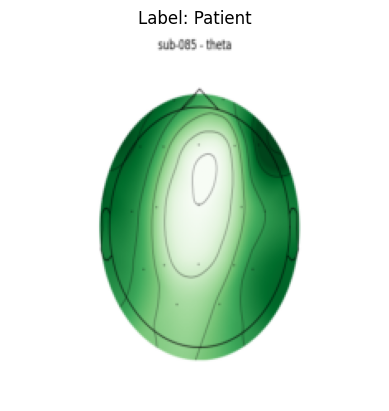

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch: tensor([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0])

Train label distribution:
label
1    207
0    101
Name: count, dtype: int64

Val label distribution:
label
1    44
0    22
Name: count, dtype: int64

Test label distribution:
label
1    44
0    22
Name: count, dtype: int64
Train missing images: 0
Val missing images: 0
Test missing images: 0

Train batch label distribution (from DataLoader): Counter({1: 207, 0: 101})


In [ ]:
# This cell imports required Python libraries for data processing, model building, and evaluation.
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
from google.colab import drive
import matplotlib.pyplot as plt
from collections import Counter

# Mount Google Drive
drive.mount('/content/drive')

# Paths to new CSV files
base_dir = "/content/drive/MyDrive/AD-DATA/csvs"
train_csv = os.path.join(base_dir, "train.csv")
val_csv = os.path.join(base_dir, "val.csv")
test_csv = os.path.join(base_dir, "test.csv")

# Image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Updated Dataset class
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image']  # direct absolute path
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])  # ✅ ensure int labels
        if self.transform:
            image = self.transform(image)
        return image, label

# Create datasets
train_dataset = EEGDataset(train_csv, transform=transform)
val_dataset = EEGDataset(val_csv, transform=transform)
test_dataset = EEGDataset(test_csv, transform=transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Datasets and loaders ready ✅")

# Verification
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

# Sample check
sample_img, sample_label = train_dataset[0]
print("Label:", sample_label)

plt.imshow(sample_img.permute(1, 2, 0))
plt.title(f"Label: {'Patient' if sample_label == 1 else 'Control'}")
plt.axis('off')
plt.show()

# Batch check
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch:", labels)

# ================================
# Extra Sanity Checks
# ================================
# 1. Label distribution from CSVs
for split, csv_file in zip(["Train", "Val", "Test"], [train_csv, val_csv, test_csv]):
    df = pd.read_csv(csv_file)
    print(f"\n{split} label distribution:")
    print(df['label'].value_counts())

# 2. Missing images check
for split, csv_file in zip(["Train", "Val", "Test"], [train_csv, val_csv, test_csv]):
    df = pd.read_csv(csv_file)
    missing = [p for p in df['image'] if not os.path.exists(p)]
    print(f"{split} missing images: {len(missing)}")
    if missing:
        print(missing[:5])  # show first few

# 3. DataLoader label distribution check
train_labels = []
for _, labels in train_loader:
    train_labels.extend(labels.tolist())
print("\nTrain batch label distribution (from DataLoader):", Counter(train_labels))


In [ ]:
# ==============================================
# CNN Models for AD Classification
# ==============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm import tqdm
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==============================================
# BASE MODEL: EEGCNN
# ==============================================
class EEGCNN(nn.Module):
    def __init__(self):
        super(EEGCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 112x112

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 56x56

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 28x28
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)  # Binary output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ==============================================
# EXTENDED MODEL: EEGCNN_Max
# ==============================================
class EEGCNN_Max(nn.Module):
    def __init__(self):
        super(EEGCNN_Max, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 112x112

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 56x56

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 28x28

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 14x14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ==============================================
# TRAINING PIPELINE (CNN_Max)
# ==============================================
# Augmentations for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

# Validation / test transforms
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Reload datasets
train_dataset = EEGDataset(train_csv, transform=train_transform)
val_dataset = EEGDataset(val_csv, transform=val_test_transform)
test_dataset = EEGDataset(test_csv, transform=val_test_transform)

# Compute class weights
labels_np = np.array(train_dataset.data['label'])
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels_np),
                                     y=labels_np)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# WeightedRandomSampler
class_sample_count = np.array([len(np.where(labels_np == t)[0]) for t in np.unique(labels_np)])
weights = 1. / class_sample_count
samples_weights = np.array([weights[t] for t in labels_np])
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# Model, Loss, Optimizer, Scheduler
model = EEGCNN_Max().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor[1])
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training loop
best_val_acc = 0
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) >= 0.5
            correct += (preds.float() == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/AD-DATA/best_cnn_max.pth")
        print("✅ Best model saved!")

    scheduler.step()

print(f"Training complete. Best Val Acc: {best_val_acc:.4f}")


# ==============================================
# TESTING & EVALUATION (CNN_Max)
# ==============================================
best_model = EEGCNN_Max().to(device)
best_model.load_state_dict(torch.load("/content/drive/MyDrive/AD-DATA/best_cnn_max.pth"))
best_model.eval()

all_labels, all_preds = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(labels.numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=["Control (0)", "Patient (1)"])

print(f"✅ CNN_Max Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Epoch 1/10: 100%|██████████| 20/20 [00:07<00:00,  2.62it/s]


Epoch 1/10 | Train Loss: 2.8096 | Val Loss: 0.8257 | Val Acc: 0.6818
✅ Best model saved!


Epoch 2/10: 100%|██████████| 20/20 [00:05<00:00,  3.70it/s]


Epoch 2/10 | Train Loss: 2.2060 | Val Loss: 0.9005 | Val Acc: 0.6515


Epoch 3/10: 100%|██████████| 20/20 [00:07<00:00,  2.58it/s]


...

Epoch 8/10 | Train Loss: 0.5462 | Val Loss: 0.5361 | Val Acc: 0.5909


Epoch 9/10: 100%|██████████| 20/20 [00:05<00:00,  3.67it/s]


Epoch 9/10 | Train Loss: 0.5506 | Val Loss: 0.5588 | Val Acc: 0.5303


Epoch 10/10: 100%|██████████| 20/20 [00:05<00:00,  3.91it/s]


Epoch 10/10 | Train Loss: 0.5270 | Val Loss: 0.5793 | Val Acc: 0.5152
Training complete. Best Val Acc: 0.7727
✅ CNN_Max Test Accuracy: 0.7273

Confusion Matrix:
 [[ 7 15]
 [ 3 41]]

Classification Report:
               precision    recall  f1-score   support

 Control (0)       0.70      0.32      0.44        22
 Patient (1)       0.73      0.93      0.82        44

    accuracy                           0.73        66
   macro avg       0.72      0.62      0.63        66
weighted avg       0.72      0.73      0.69        66



In [ ]:
# Model: ResNet50 Fine-tuning 1
# Category: ResNet | Category Rank: 2 | Overall Rank: 2
# Validation Accuracy: 0.7424 | Test Accuracy: 0.7879
# Note: Precision, Recall, and F1 were not found in outputs for this model.
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
# =======================
# EEG Alzheimer's Detection - ResNet50 Fine-tuning
# =======================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import drive

# ----- MOUNT DRIVE -----
drive.mount('/content/drive')

# =======================
# DATASET LOADING
# =======================
# Paths to CSV files
base_dir = "/content/drive/MyDrive/AD-DATA/csvs"
train_csv = os.path.join(base_dir, "train.csv")
val_csv = os.path.join(base_dir, "val.csv")
test_csv = os.path.join(base_dir, "test.csv")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset class
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image']
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# Load datasets
train_dataset = EEGDataset(train_csv, transform=train_transform)
val_dataset = EEGDataset(val_csv, transform=val_test_transform)
test_dataset = EEGDataset(test_csv, transform=val_test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# =======================
# MODEL SETUP
# =======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Modify FC layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
best_val_acc = 0
best_model_path = "/content/drive/MyDrive/AD-DATA/resnet50_best.pth"
log = []

# =======================
# WARMUP TRAINING (HEAD ONLY)
# =======================
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
print("🔹 Warmup: training head only for 3 epochs")
for epoch in range(3):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}/3"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    correct = 0
    val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    print(f"Warmup Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at {best_model_path}")

# =======================
# FULL FINE-TUNING
# =======================
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at {best_model_path}")

    log.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc})

# Save training log
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_path = f"/content/drive/MyDrive/AD-DATA/resnet50_training_log_{timestamp}.csv"
pd.DataFrame(log).to_csv(log_path, index=False)
print(f"✅ Training log saved to {log_path}")

# =======================
# TEST EVALUATION
# =======================
model.load_state_dict(torch.load(best_model_path))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control", "Patient"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 308, Val: 66, Test: 66
🔹 Warmup: training head only for 3 epochs


Warmup 1/3: 100%|██████████| 20/20 [00:05<00:00,  3.51it/s]


Warmup Epoch 1 | Train Loss: 0.6651 | Val Loss: 0.6397 | Val Acc: 0.6667
✅ Best model saved at /content/drive/MyDrive/AD-DATA/resnet50_best.pth


Warmup 2/3: 100%|██████████| 20/20 [00:05<00:00,  3.70it/s]


Warmup Epoch 2 | Train Loss: 0.6360 | Val Loss: 0.6385 | Val Acc: 0.6667


...

Epoch 18/20 | Train Loss: 0.2772 | Val Loss: 0.6766 | Val Acc: 0.7121


Epoch 19/20: 100%|██████████| 20/20 [00:07<00:00,  2.79it/s]


Epoch 19/20 | Train Loss: 0.3346 | Val Loss: 0.5826 | Val Acc: 0.6364


Epoch 20/20: 100%|██████████| 20/20 [00:06<00:00,  3.05it/s]


Epoch 20/20 | Train Loss: 0.3388 | Val Loss: 0.5337 | Val Acc: 0.7424
✅ Training log saved to /content/drive/MyDrive/AD-DATA/resnet50_training_log_2025-08-12_13-15-31.csv
✅ Test Accuracy: 0.7879
Confusion Matrix:
 [[10 12]
 [ 2 42]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.83      0.45      0.59        22
     Patient       0.78      0.95      0.86        44

    accuracy                           0.79        66
   macro avg       0.81      0.70      0.72        66
weighted avg       0.80      0.79      0.77        66



In [ ]:
# Model: ResNet50 Hybrid Training 2
# Category: ResNet | Category Rank: 4 | Overall Rank: 5
# Validation Accuracy: 0.7121 | Test Accuracy: 0.7879
# Note: Precision, Recall, and F1 were not found in outputs for this model.
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
# =======================
# EEG Alzheimer's Detection - ResNet50 Hybrid Training (No Early Stop)
# =======================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import drive

# ----- MOUNT DRIVE -----
drive.mount('/content/drive')

# =======================
# DATASET LOADING
# =======================
base_dir = "/content/drive/MyDrive/AD-DATA/csvs"
train_csv = os.path.join(base_dir, "train.csv")
val_csv = os.path.join(base_dir, "val.csv")
test_csv = os.path.join(base_dir, "test.csv")

# Transforms (balanced augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset class
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image']
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# Load datasets
train_dataset = EEGDataset(train_csv, transform=train_transform)
val_dataset = EEGDataset(val_csv, transform=val_test_transform)
test_dataset = EEGDataset(test_csv, transform=val_test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# =======================
# MODEL SETUP
# =======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Freeze only first conv + BN (gradual unfreezing approach)
for name, param in model.named_parameters():
    if name.startswith("conv1") or name.startswith("bn1"):
        param.requires_grad = False

# Modify final FC for binary classification
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)
model = model.to(device)

# Layer-wise learning rates
params = [
    {"params": model.conv1.parameters(), "lr": 1e-5},
    {"params": model.bn1.parameters(), "lr": 1e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 3e-5},
    {"params": model.layer3.parameters(), "lr": 1e-4},
    {"params": model.layer4.parameters(), "lr": 3e-4},
    {"params": model.fc.parameters(), "lr": 1e-3}
]

criterion = nn.BCEWithLogitsLoss()
best_val_acc = 0
best_model_path = "/content/drive/MyDrive/AD-DATA/resnet50_best.pth"
log = []

# =======================
# WARMUP TRAINING (HEAD ONLY)
# =======================
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
print("🔹 Warmup: training head only for 3 epochs")
for epoch in range(3):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}/3"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    print(f"Warmup Epoch {epoch+1} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at {best_model_path}")

# =======================
# FULL FINE-TUNING (NO EARLY STOP)
# =======================
# Unfreeze all layers & set layer-wise learning rates
for param in model.parameters():
    param.requires_grad = True
optimizer = optim.Adam(params)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

num_epochs = 15  # fixed number of epochs

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at {best_model_path}")

    log.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc})

# Save training log
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_path = f"/content/drive/MyDrive/AD-DATA/resnet50_training_log_{timestamp}.csv"
pd.DataFrame(log).to_csv(log_path, index=False)
print(f"✅ Training log saved to {log_path}")

# =======================
# TEST EVALUATION
# =======================
model.load_state_dict(torch.load(best_model_path))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control", "Patient"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 308, Val: 66, Test: 66
🔹 Warmup: training head only for 3 epochs


Warmup 1/3: 100%|██████████| 20/20 [00:08<00:00,  2.39it/s]


Warmup Epoch 1 | Train Loss: 0.6650 | Val Loss: 0.6341 | Val Acc: 0.6667
✅ Best model saved at /content/drive/MyDrive/AD-DATA/resnet50_best.pth


Warmup 2/3: 100%|██████████| 20/20 [00:07<00:00,  2.78it/s]


Warmup Epoch 2 | Train Loss: 0.6238 | Val Loss: 0.6280 | Val Acc: 0.6667


...

Epoch 13/15 | Train Loss: 0.1996 | Val Loss: 0.6090 | Val Acc: 0.6970


Epoch 14/15: 100%|██████████| 20/20 [00:07<00:00,  2.75it/s]


Epoch 14/15 | Train Loss: 0.2354 | Val Loss: 0.5590 | Val Acc: 0.7727


Epoch 15/15: 100%|██████████| 20/20 [00:06<00:00,  3.00it/s]


Epoch 15/15 | Train Loss: 0.2369 | Val Loss: 0.6187 | Val Acc: 0.7121
✅ Training log saved to /content/drive/MyDrive/AD-DATA/resnet50_training_log_2025-08-12_17-52-22.csv
✅ Test Accuracy: 0.7879
Confusion Matrix:
 [[ 9 13]
 [ 1 43]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.90      0.41      0.56        22
     Patient       0.77      0.98      0.86        44

    accuracy                           0.79        66
   macro avg       0.83      0.69      0.71        66
weighted avg       0.81      0.79      0.76        66



In [ ]:
# Model: Inception v3 Fine-tuning
# Category: Inception | Category Rank: 2 | Overall Rank: 12
# Validation Accuracy: 0.6515 | Test Accuracy: 0.7424
# Note: Precision, Recall, and F1 were not found in outputs for this model.
# This cell imports required Python libraries for data processing, model building, and evaluation.
# This cell imports necessary Python libraries and modules for the notebook.
# =======================
# EEG Alzheimer's Detection - Inception v3 Fine-tuning
# =======================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.models import Inception_V3_Weights
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pandas as pd
import os
from PIL import Image
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import drive

# ----- MOUNT DRIVE -----
drive.mount('/content/drive')

# =======================
# DATASET LOADING
# =======================
base_dir = "/content/drive/MyDrive/AD-DATA/csvs"
train_csv = os.path.join(base_dir, "train.csv")
val_csv = os.path.join(base_dir, "val.csv")
test_csv = os.path.join(base_dir, "test.csv")

# Transforms for Inception (requires 299x299)
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])
val_test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

# Dataset class
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['image']
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# Load datasets
train_dataset = EEGDataset(train_csv, transform=train_transform)
val_dataset = EEGDataset(val_csv, transform=val_test_transform)
test_dataset = EEGDataset(test_csv, transform=val_test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# =======================
# MODEL SETUP
# =======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Inception_V3_Weights.DEFAULT
model = models.inception_v3(weights=weights)

# Modify the final fully connected layers for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# =======================
# TRAINING LOOP
# =======================
num_epochs = 15
best_val_acc = 0
best_model_path = "/content/drive/MyDrive/AD-DATA/inceptionv3_best.pth"
log = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs, aux_outputs = model(images)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)
        loss = loss1 + 0.4 * loss2  # Weighted sum of main and aux losses
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):  # Inception returns tuple in training mode
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at {best_model_path}")

    log.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc})

# Save training log
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_path = f"/content/drive/MyDrive/AD-DATA/inceptionv3_training_log_{timestamp}.csv"
pd.DataFrame(log).to_csv(log_path, index=False)
print(f"✅ Training log saved to {log_path}")

# =======================
# TEST EVALUATION
# =======================
model.load_state_dict(torch.load(best_model_path))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        preds = (torch.sigmoid(outputs) >= 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control", "Patient"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 308, Val: 66, Test: 66


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 157MB/s] 
Epoch 1/15: 100%|██████████| 20/20 [00:09<00:00,  2.11it/s]


Epoch 1/15 | Train Loss: 0.8982 | Val Loss: 0.5243 | Val Acc: 0.7879
✅ Best model saved at /content/drive/MyDrive/AD-DATA/inceptionv3_best.pth


Epoch 2/15: 100%|██████████| 20/20 [00:11<00:00,  1.81it/s]


Epoch 2/15 | Train Loss: 0.7153 | Val Loss: 0.5623 | Val Acc: 0.6667


...

Epoch 13/15 | Train Loss: 0.1534 | Val Loss: 0.6935 | Val Acc: 0.7121


Epoch 14/15: 100%|██████████| 20/20 [00:08<00:00,  2.30it/s]


Epoch 14/15 | Train Loss: 0.1501 | Val Loss: 0.7818 | Val Acc: 0.7273


Epoch 15/15: 100%|██████████| 20/20 [00:08<00:00,  2.36it/s]


Epoch 15/15 | Train Loss: 0.2015 | Val Loss: 0.7387 | Val Acc: 0.7424
✅ Training log saved to /content/drive/MyDrive/AD-DATA/inceptionv3_training_log_2025-08-16_20-43-44.csv
✅ Test Accuracy: 0.8030
Confusion Matrix:
 [[11 11]
 [ 2 42]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.85      0.50      0.63        22
     Patient       0.79      0.95      0.87        44

    accuracy                           0.80        66
   macro avg       0.82      0.73      0.75        66
weighted avg       0.81      0.80      0.79        66



In [ ]:
#VGG16-1
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd, os, numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
from google.colab import drive

# ====== DRIVE ======
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/AD-DATA/csvs"
TRAIN_CSV, VAL_CSV, TEST_CSV = [os.path.join(BASE_DIR, f) for f in ["train.csv","val.csv","test.csv"]]
BEST_MODEL_PATH = "/content/drive/MyDrive/AD-DATA/vgg16_stable_best.pth"

# ====== TRANSFORMS ======
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# ====== DATASET ======
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img_path = str(self.data.iloc[idx]['image'])
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform: image = self.transform(image)
        return image, label

train_dataset = EEGDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = EEGDataset(VAL_CSV, transform=val_test_transform)
test_dataset  = EEGDataset(TEST_CSV, transform=val_test_transform)

# ====== SAMPLER (balance classes) ======
labels_train = [lbl for _, lbl in train_dataset]
class_counts = np.bincount(labels_train)
class_weights = torch.tensor([len(labels_train)/c for c in class_counts], dtype=torch.float)
sample_weights = [class_weights[l] for l in labels_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====== MODEL ======
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 1)
)
model = model.to(DEVICE)

# ====== LOSS + OPTIMIZER ======
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weights[1]/class_weights[0]]).to(DEVICE))
params = [
    {"params": model.features.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
]
optimizer = optim.AdamW(params, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)
scaler = torch.cuda.amp.GradScaler()

# ====== TRAIN LOOP ======
EPOCHS = 25
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    running_loss = 0.0

    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    scheduler.step()

    # ===== Validation =====
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            outputs = model(images)
            preds = (torch.sigmoid(outputs)>=0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"[Epoch {epoch+1}/{EPOCHS}] Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved.")

# ====== TEST ======
print("\nLoading best model for test...")
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    print("✅ Loaded best saved model.")
else:
    print("⚠️ No saved model found — using last trained weights.")

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        preds = (torch.sigmoid(outputs)>=0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
acc = accuracy_score(all_labels, all_preds)
print(f"\n✅ Test Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control","Patient"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-2534745664.py:79: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[Epoch 1/25] Val Acc: 0.3333
✅ Best model saved.


[Epoch 2/25] Val Acc: 0.3788
✅ Best model saved.


[Epoch 3/25] Val Acc: 0.3182


...

[Epoch 21/25] Val Acc: 0.7879


[Epoch 22/25] Val Acc: 0.7576


[Epoch 23/25] Val Acc: 0.7576


[Epoch 24/25] Val Acc: 0.7576


[Epoch 25/25] Val Acc: 0.7576

Loading best model for test...
✅ Loaded best saved model.

✅ Test Accuracy: 0.7424
Confusion Matrix:
 [[12 10]
 [ 7 37]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.63      0.55      0.59        22
     Patient       0.79      0.84      0.81        44

    accuracy                           0.74        66
   macro avg       0.71      0.69      0.70        66
weighted avg       0.74      0.74      0.74        66



In [ ]:
# ==========================
# VGG19 Alzheimer’s (Stable)
# ==========================
import os, numpy as np, pandas as pd, random
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from google.colab import drive

# ====== DRIVE ======
drive.mount('/content/drive', force_remount=False)
BASE_DIR = "/content/drive/MyDrive/AD-DATA/csvs"
TRAIN_CSV, VAL_CSV, TEST_CSV = [os.path.join(BASE_DIR,f) for f in ["train.csv","val.csv","test.csv"]]
BEST_MODEL_PATH = "/content/drive/MyDrive/AD-DATA/vgg19_stable_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====== SEED ======
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ====== TRANSFORMS ======
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9,1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# ====== DATASET ======
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, int(row['label'])

train_ds = EEGDataset(TRAIN_CSV, transform=train_transform)
val_ds   = EEGDataset(VAL_CSV, transform=val_test_transform)
test_ds  = EEGDataset(TEST_CSV, transform=val_test_transform)

labels_train = [lbl for _, lbl in train_ds]
class_counts = np.bincount(labels_train)
weights = len(labels_train) / (len(class_counts) * class_counts)
sample_weights = [weights[l] for l in labels_train]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# ====== Weighted BCE with Label Smoothing ======
class BCEWithLogitsLossSmooth(nn.Module):
    def __init__(self, pos_weight, smoothing=0.1):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.smoothing = smoothing
    def forward(self, logits, targets):
        targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, targets)

pos_weight = torch.tensor([class_counts[0]/class_counts[1]]).to(DEVICE)  # balance control/patient
criterion = BCEWithLogitsLossSmooth(pos_weight=pos_weight, smoothing=0.1)

# ====== MODEL ======
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 1)
)
model = model.to(DEVICE)

# Freeze low conv layers first 5 epochs
for param in model.features[:20].parameters():
    param.requires_grad = False

# ====== OPTIMIZER + SCHEDULER ======
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

scaler = torch.amp.GradScaler('cuda')

# ====== TRAIN LOOP ======
best_val_balacc = 0
EPOCHS = 25

for epoch in range(1,EPOCHS+1):
    # ---- Train ----
    model.train()
    for x,y in tqdm(train_loader, desc=f"Train {epoch}"):
        x,y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            out = model(x); loss = criterion(out,y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

    # ---- Val ----
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            p = torch.sigmoid(model(x))
            pred = (p>=0.5).float()
            preds.extend(pred.cpu().numpy().ravel()); labels.extend(y.cpu().numpy().ravel())
    val_acc = accuracy_score(labels,preds)
    val_balacc = balanced_accuracy_score(labels,preds)
    print(f"[Epoch {epoch}/{EPOCHS}] Val Acc: {val_acc:.4f} | Balanced Acc: {val_balacc:.4f}")
    scheduler.step(val_balacc)

    if val_balacc > best_val_balacc:
        best_val_balacc = val_balacc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("✅ Best model saved.")

    # unfreeze after 5 epochs
    if epoch==5:
        for param in model.features[:20].parameters():
            param.requires_grad = True

# ====== TEST (with TTA) ======
print("\nLoading best model for test...")
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

def tta_predict(x):
    with torch.no_grad():
        p1 = torch.sigmoid(model(x))
        p2 = torch.sigmoid(model(torch.flip(x,[3])))  # horizontal flip
        return (p1+p2)/2

all_preds, all_labels = [], []
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        p = tta_predict(x)
        pred = (p>=0.5).float()
        all_preds.extend(pred.cpu().numpy().ravel())
        all_labels.extend(y.cpu().numpy().ravel())

acc = accuracy_score(all_labels, all_preds)
balacc = balanced_accuracy_score(all_labels, all_preds)
print(f"\n✅ Test Accuracy: {acc:.4f} | Balanced Acc: {balacc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control","Patient"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 308, Val: 66, Test: 66


Train 1: 100%|██████████| 20/20 [00:03<00:00,  5.21it/s]


[Epoch 1/25] Val Acc: 0.3333 | Balanced Acc: 0.5000
✅ Best model saved.


Train 2: 100%|██████████| 20/20 [00:05<00:00,  3.70it/s]


[Epoch 2/25] Val Acc: 0.3333 | Balanced Acc: 0.5000


...

[Epoch 23/25] Val Acc: 0.7424 | Balanced Acc: 0.7727


Train 24: 100%|██████████| 20/20 [00:17<00:00,  1.12it/s]


[Epoch 24/25] Val Acc: 0.7273 | Balanced Acc: 0.7500


Train 25: 100%|██████████| 20/20 [00:04<00:00,  4.06it/s]


[Epoch 25/25] Val Acc: 0.7121 | Balanced Acc: 0.7386

Loading best model for test...

✅ Test Accuracy: 0.7424 | Balanced Acc: 0.7386
Confusion Matrix:
 [[16  6]
 [11 33]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.59      0.73      0.65        22
     Patient       0.85      0.75      0.80        44

    accuracy                           0.74        66
   macro avg       0.72      0.74      0.72        66
weighted avg       0.76      0.74      0.75        66



In [ ]:
# ==========================
# Hybrid Ensemble: VGG16 + CNN
# ==========================
import torch, torch.nn as nn, torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd, os
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===== DEVICE =====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== TRANSFORMS =====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ===== DATASET =====
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img_path = str(self.data.iloc[idx]['image'])
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform: image = self.transform(image)
        return image, label

# ==========================
# Define Models
# ==========================

# --- Custom CNN ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# --- VGG16 ---
def build_vgg16():
    vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    for param in vgg.features.parameters():  # freeze convolutional layers
        param.requires_grad = False
    num_features = vgg.classifier[6].in_features
    vgg.classifier[6] = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return vgg

# ==========================
# Ensemble Wrapper
# ==========================
class HybridEnsemble(nn.Module):
    def __init__(self, model1, model2):
        super(HybridEnsemble, self).__init__()
        self.model1 = model1
        self.model2 = model2
    def forward(self, x):
        out1 = self.model1(x)
        out2 = self.model2(x)
        out = (out1 + out2) / 2.0   # average logits
        return out

# ==========================
# Training Function
# ==========================
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    best_acc = 0

    for epoch in range(epochs):
        # Train
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        # Validate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = torch.sigmoid(model(x))
                preds = (out >= 0.5).float().cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y.cpu().numpy())
        val_acc = accuracy_score(all_labels, all_preds)
        print(f"[Epoch {epoch+1}/{epochs}] Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "hybrid_best.pth")
            print("✅ Best model saved.")

# ==========================
# TEST Function
# ==========================
def test_model(model, test_loader):
    model.load_state_dict(torch.load("hybrid_best.pth", map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = torch.sigmoid(model(x))
            preds = (out >= 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n✅ Test Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
    print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control","Patient"]))
    return acc

# ==========================
# MAIN
# ==========================
# Update your CSV paths here
TRAIN_CSV = "/content/drive/MyDrive/AD-DATA/csvs/train.csv"
VAL_CSV   = "/content/drive/MyDrive/AD-DATA/csvs/val.csv"
TEST_CSV  = "/content/drive/MyDrive/AD-DATA/csvs/test.csv"

train_dataset = EEGDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = EEGDataset(VAL_CSV, transform=val_test_transform)
test_dataset  = EEGDataset(TEST_CSV, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

cnn = SimpleCNN().to(DEVICE)
vgg16 = build_vgg16().to(DEVICE)
ensemble_model = HybridEnsemble(cnn, vgg16).to(DEVICE)

train_model(ensemble_model, train_loader, val_loader, epochs=20, lr=1e-4)
test_model(ensemble_model, test_loader)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 171MB/s]


[Epoch 1/20] Val Acc: 0.7121
✅ Best model saved.
[Epoch 2/20] Val Acc: 0.6667
[Epoch 3/20] Val Acc: 0.6667
[Epoch 4/20] Val Acc: 0.6667
[Epoch 5/20] Val Acc: 0.6970
[Epoch 6/20] Val Acc: 0.7121
[Epoch 7/20] Val Acc: 0.7424
✅ Best model saved.
[Epoch 8/20] Val Acc: 0.7273
[Epoch 9/20] Val Acc: 0.7576
✅ Best model saved.
[Epoch 10/20] Val Acc: 0.7576
[Epoch 11/20] Val Acc: 0.7576
[Epoch 12/20] Val Acc: 0.8030
✅ Best model saved.
[Epoch 13/20] Val Acc: 0.7424
[Epoch 14/20] Val Acc: 0.6364
[Epoch 15/20] Val Acc: 0.7727
[Epoch 16/20] Val Acc: 0.6970
[Epoch 17/20] Val Acc: 0.7273
[Epoch 18/20] Val Acc: 0.5606
[Epoch 19/20] Val Acc: 0.7727
[Epoch 20/20] Val Acc: 0.7727

✅ Test Accuracy: 0.7273
Confusion Matrix:
 [[11 11]
 [ 7 37]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.61      0.50      0.55        22
     Patient       0.77      0.84      0.80        44

    accuracy                           0.73        66
   macro avg       0.69

0.7272727272727273

In [ ]:
# ==========================
# Improved Hybrid CNN + VGG16
# ==========================
import torch, torch.nn as nn, torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd, os
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===== TRANSFORMS =====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ===== DATASET =====
class EEGDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img_path = str(self.data.iloc[idx]['image'])
        image = Image.open(img_path).convert("RGB")
        label = int(self.data.iloc[idx]['label'])
        if self.transform: image = self.transform(image)
        return image, label

# ===== Custom CNN branch =====
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.flatten_dim = 128 * 28 * 28

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

# ===== Hybrid CNN+VGG16 =====
class HybridCNNVGG(nn.Module):
    def __init__(self, num_classes=1):
        super(HybridCNNVGG, self).__init__()

        # VGG16 backbone
        self.vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        # Unfreeze last 2 conv blocks for fine-tuning
        for name, param in self.vgg.features.named_parameters():
            param.requires_grad = False
        for name, param in list(self.vgg.features.named_parameters())[-8:]:
            param.requires_grad = True

        self.vgg.classifier = nn.Identity()
        vgg_out_dim = 25088

        # CNN branch
        self.cnn = SimpleCNN()
        cnn_out_dim = self.cnn.flatten_dim

        # Fusion classifier
        self.classifier = nn.Sequential(
            nn.Linear(vgg_out_dim + cnn_out_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        vgg_feat = self.vgg(x)
        cnn_feat = self.cnn(x)
        fused = torch.cat([vgg_feat, cnn_feat], dim=1)
        return self.classifier(fused)

# ===== Focal Loss (better for imbalance) =====
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction
    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean() if self.reduction == "mean" else loss.sum()

# ===== Training =====
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4):
    criterion = FocalLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
    best_acc, patience, trigger = 0, 6, 0

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                preds = (torch.sigmoid(model(x)) >= 0.5).float().cpu().numpy()
                all_preds.extend(preds); all_labels.extend(y.cpu().numpy())
        val_acc = accuracy_score(all_labels, all_preds)
        print(f"[Epoch {epoch+1}/{epochs}] Val Acc: {val_acc:.4f}")
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc, trigger = val_acc, 0
            torch.save(model.state_dict(), "hybrid_cnn_vgg_best.pth")
            print("✅ Best model saved.")
        else:
            trigger += 1
            if trigger >= patience:
                print("⏹️ Early stopping.")
                break

# ===== Testing =====
def test_model(model, test_loader):
    model.load_state_dict(torch.load("hybrid_cnn_vgg_best.pth", map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = (torch.sigmoid(model(x)) >= 0.5).float().cpu().numpy()
            all_preds.extend(preds); all_labels.extend(y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n✅ Test Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
    print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=["Control","Patient"]))
    return acc

# ===== MAIN =====
TRAIN_CSV = "/content/drive/MyDrive/AD-DATA/csvs/train.csv"
VAL_CSV   = "/content/drive/MyDrive/AD-DATA/csvs/val.csv"
TEST_CSV  = "/content/drive/MyDrive/AD-DATA/csvs/test.csv"

train_dataset = EEGDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = EEGDataset(VAL_CSV, transform=val_test_transform)
test_dataset  = EEGDataset(TEST_CSV, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = HybridCNNVGG().to(DEVICE)

train_model(model, train_loader, val_loader, epochs=25, lr=1e-4)
test_model(model, test_loader)

Using device: cuda
[Epoch 1/25] Val Acc: 0.6667
✅ Best model saved.
[Epoch 2/25] Val Acc: 0.4848
[Epoch 3/25] Val Acc: 0.6667
[Epoch 4/25] Val Acc: 0.6818
✅ Best model saved.
[Epoch 5/25] Val Acc: 0.7121
✅ Best model saved.
[Epoch 6/25] Val Acc: 0.6667
[Epoch 7/25] Val Acc: 0.7727
✅ Best model saved.
[Epoch 8/25] Val Acc: 0.7121
[Epoch 9/25] Val Acc: 0.7121
[Epoch 10/25] Val Acc: 0.7727
[Epoch 11/25] Val Acc: 0.7727
[Epoch 12/25] Val Acc: 0.8030
✅ Best model saved.
[Epoch 13/25] Val Acc: 0.7727
[Epoch 14/25] Val Acc: 0.7424
[Epoch 15/25] Val Acc: 0.7273
[Epoch 16/25] Val Acc: 0.6970
[Epoch 17/25] Val Acc: 0.7273
[Epoch 18/25] Val Acc: 0.7424
⏹️ Early stopping.

✅ Test Accuracy: 0.7273
Confusion Matrix:
 [[ 8 14]
 [ 4 40]]

Classification Report:
               precision    recall  f1-score   support

     Control       0.67      0.36      0.47        22
     Patient       0.74      0.91      0.82        44

    accuracy                           0.73        66
   macro avg       0.70  

0.7272727272727273